# PRACTICA: Embeddings y Vector Database (Azure AI Search)

> Formato: MD. Entrega en la carpeta del tema. Esta práctica tiene dos partes: documentación del wizard (Import data) y ejecución de búsquedas.

---

## Resumen

Objetivo: Crear y documentar un pipeline de indexación por medio del wizard "Import data" del portal de Azure (vectorización integrada). Posteriormente realizar búsquedas contra el índice creado: Vector Search, Hybrid Search, Semantic Search y Semantic Hybrid Search. Incluir capturas, explicaciones y resultados.

---

## Requisitos previos

- Cuenta Azure con recurso Azure AI Search (Basic o superior recomendado).
- Contenedor en Azure Blob Storage con documentos (PDF/DOCX/HTML).
- Recurso Azure OpenAI con deployment de embeddings.

---

## PARTE 1 — Creación del índice mediante el wizard (Import data)

Esta parte es documental: seguir el wizard en el portal para crear el índice. Entregar en este archivo las capturas y explicaciones.

Pasos (portal):
1. En el recurso de **Azure AI Search** seleccionar **Import data**.
2. Elegir escenario: **RAG** (no agentic retrieval).
3. Conectar a **Azure Blob Storage** (seleccionar contenedor con documentos). Autenticación por Managed Identity o clave.
4. En vectorización elegir proveedor (Azure OpenAI / Foundry) y deployment de embeddings.
5. Revisar la inferencia del esquema y ajustar campos si hace falta.
6. Finalizar: el wizard crea Data Source, Index, Skillset (si se activó enrichment), Indexer y Knowledge Store opcional.

### Capturas y explicaciones que hay que adjuntar

- **ÍNDICE (Index schema)**: capturar la definición del índice creado.
- **SEMANTIC CONFIGURATION**: captura del objeto semántico creado. Explicar qué es y cómo está configurado.
- **VECTOR PROFILE**: captura de la sección `Algorithm` y `Vectorizer` del índice. Explicar cada una de ellas y cómo están configuradas
- **SKILLSET**: captura del skillset generado por el wizard. Explicar qué es y los pasos que contiene
---


## PARTE 1 — Creación del índice mediante el wizard (Import data)

A continuación, se detalla paso a paso el proceso de configuración realizado a través del portal de Azure.

### 1. Despliegue del Recurso e Inicio de Importación
Se ha procedido a la creación del recurso **Azure AI Search**. En la fase inicial, se utiliza la herramienta **"Import data"** seleccionando el escenario **RAG (Retrieval-Augmented Generation)**. 
- **Captura 1**: Se observa la interfaz del portal donde se inicia el proceso de conexión con el origen de datos en **Azure Blob Storage**.



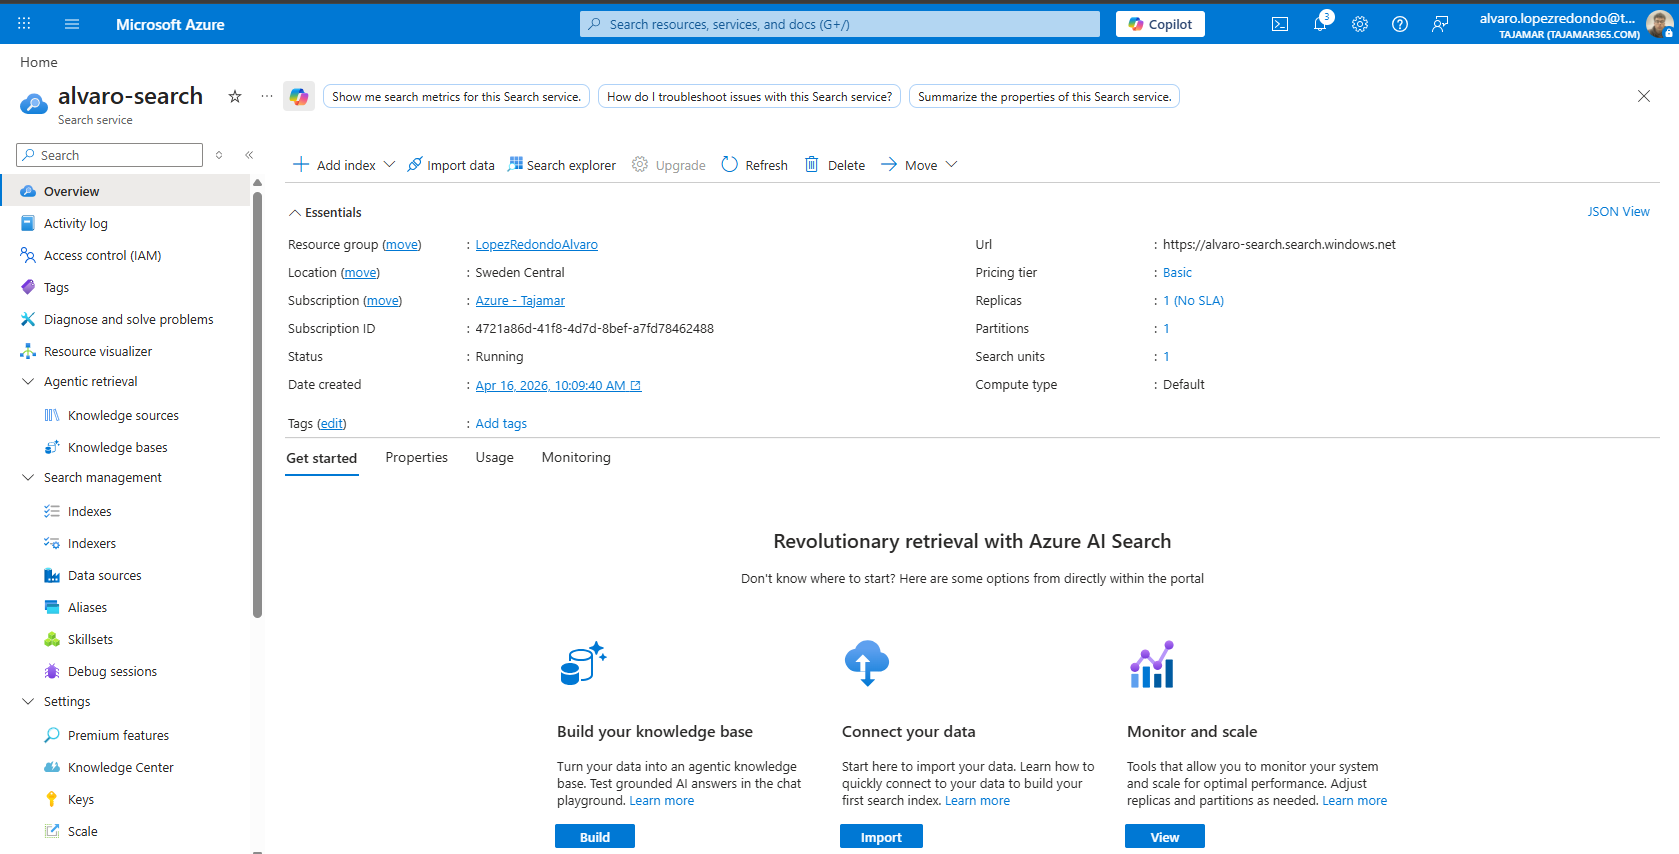

Esta imagen muestra el portal de Microsoft Azure durante la configuración de un servicio de búsqueda inteligente (AI Search) llamado alvaro-search. El usuario se encuentra en el primer paso del asistente para importar y vectorizar datos.1. Flujo del Proceso (Panel Lateral)El asistente consta de 5 etapas clave:
🔵 Connect to your data (Paso actual)
⚪ Vectorize your text
⚪ Vectorize and enrich your images
⚪ Advanced settings
⚪ Review and create

2. Detalles de la Configuración (Azure Blob Storage)
En esta sección se define de dónde extraerá la información la IA:
Campo   Valor seleccionado
Subscription    Azure - Tajamar
Storage account aisearchalvaro
Blob container  blobalvaro
Parsing mode    Default

3. Opciones de Seguridad y SincronizaciónEn la parte inferior se encuentran dos opciones de configuración avanzada:
Enable deletion tracking: (Desactivado) Sirve para que, si borras un archivo en el storage, se borre automáticamente del índice de búsqueda.
Authenticate using managed identity: (Desactivado) Permite conectar los servicios de forma más segura sin usar claves manuales.

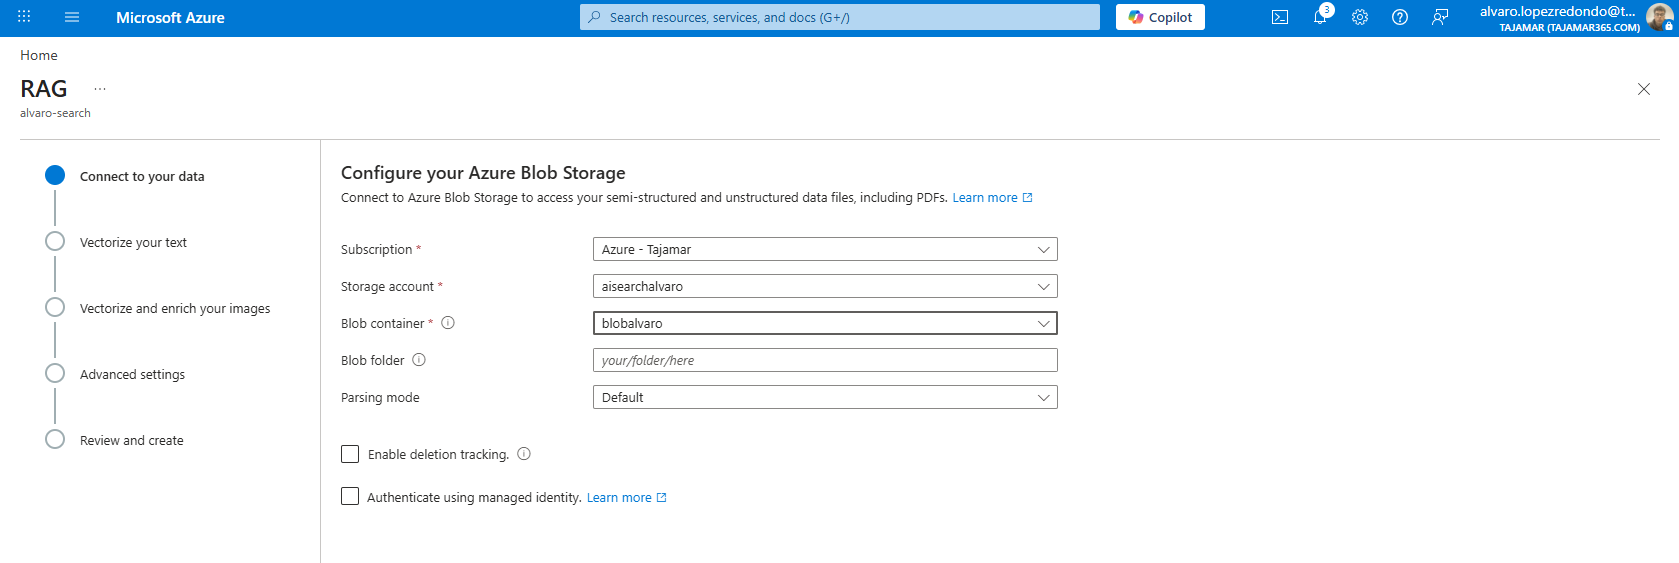

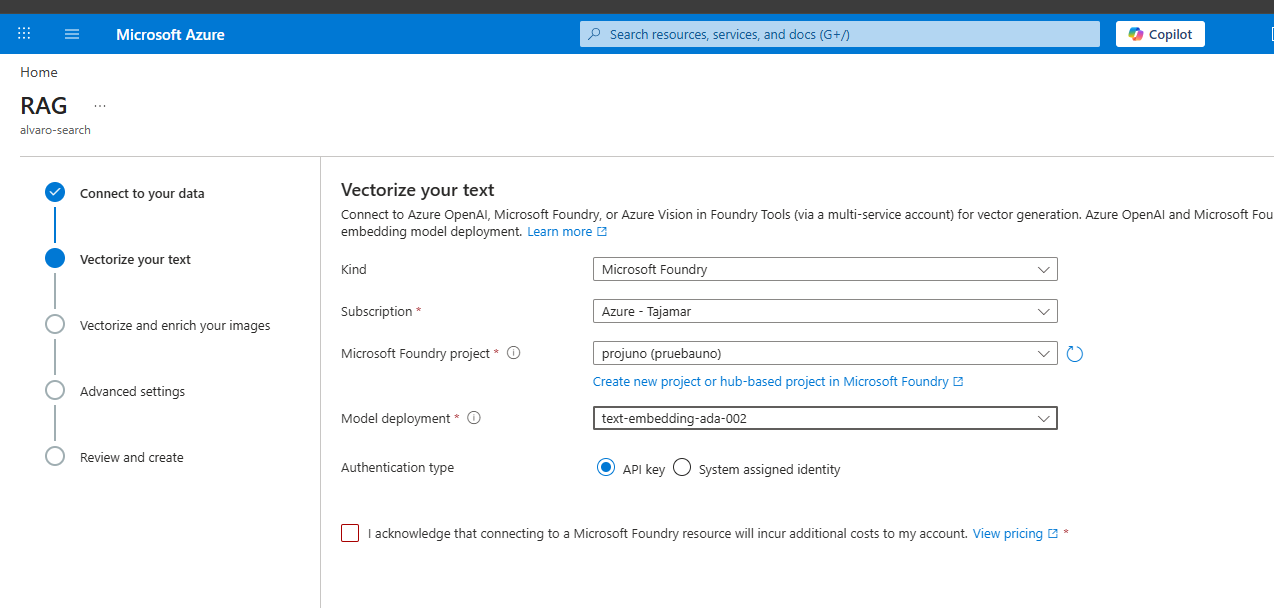

INDEXES

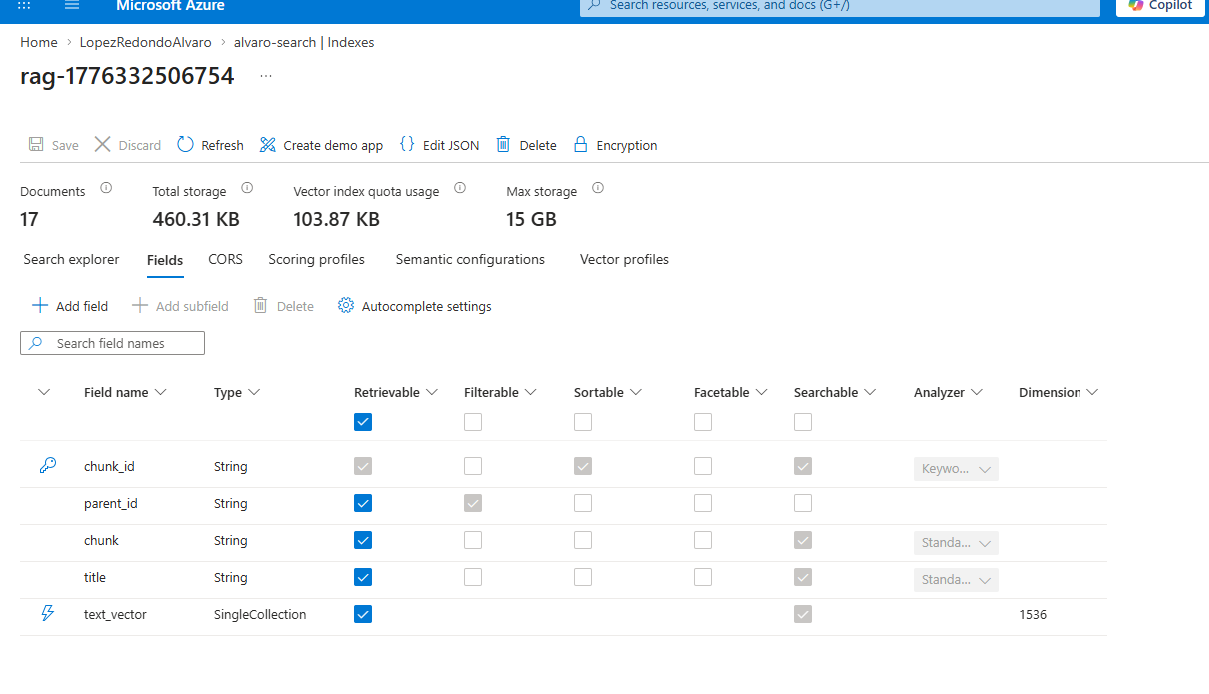

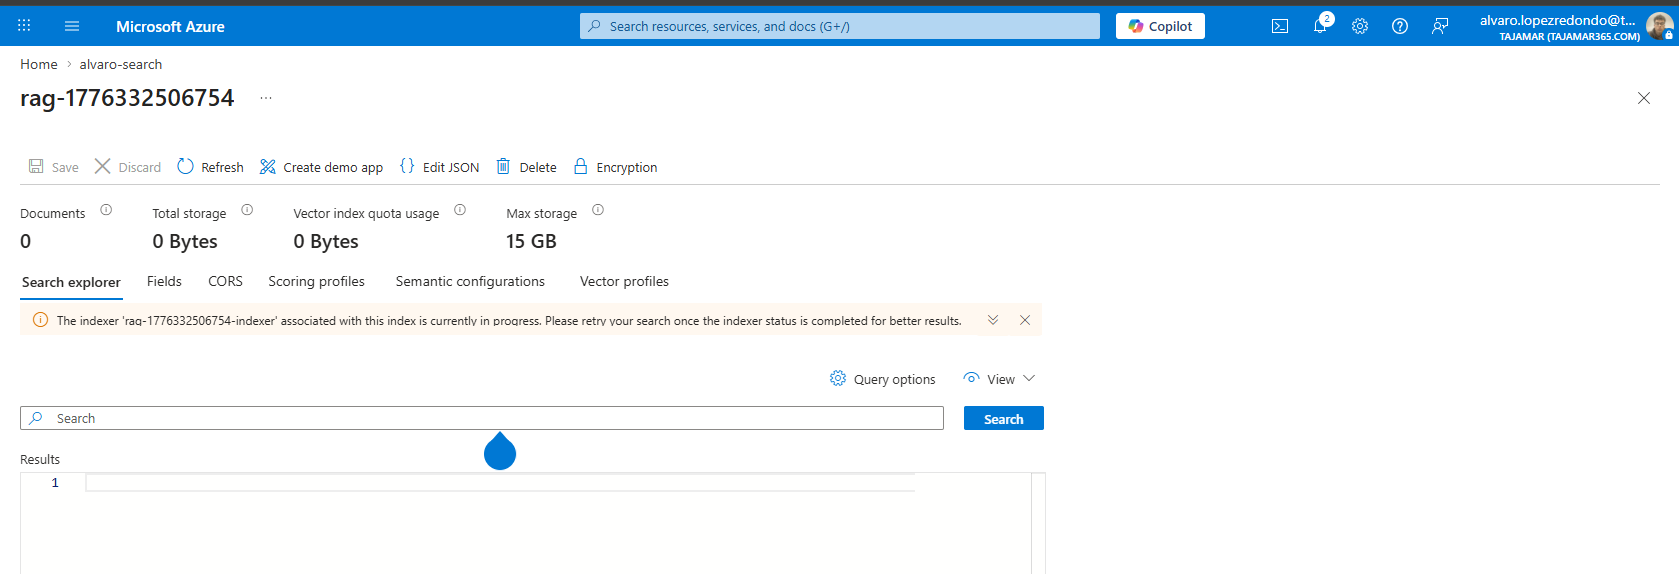

Esta captura muestra los detalles del objeto de Configuración Semántica creado para tu índice rag-1776332506754. Esta es la pieza clave que permite que tu buscador no solo encuentre palabras exactas, sino que entienda conceptos.


¿Qué es la Configuración Semántica?
Es una capacidad de Azure AI Search que utiliza modelos de aprendizaje profundo para mejorar la relevancia de los resultados. Su función principal es el Semantic Ranking: después de que el motor de búsqueda encuentra documentos, esta configuración le dice a la IA en qué campos debe fijarse prioritariamente para entender de qué trata el documento y reordenar los resultados según su significado real.

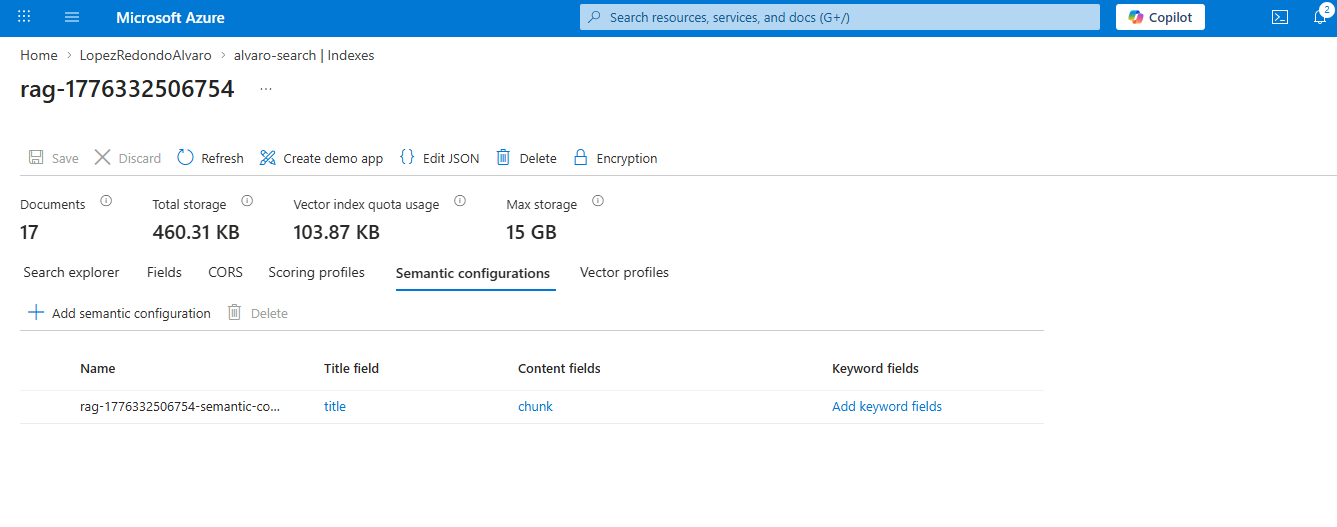

ALGORITHMS Y VECTORIZERS

In [4]:
"vectorSearch": {
    "algorithms": [
      {
        "name": "rag-1776332506754-algorithm",
        "kind": "hnsw",
        "hnswParameters": {
          "metric": "cosine",
          "m": 4,
          "efConstruction": 400,
          "efSearch": 500
        }
      }
    ],
    "profiles": [
      {
        "name": "rag-1776332506754-aiFoundryCatalog-text-profile",
        "algorithm": "rag-1776332506754-algorithm",
        "vectorizer": "rag-1776332506754-aiFoundryCatalog-text-vectorizer"
      }
    ],
    "vectorizers": [
      {
        "name": "rag-1776332506754-aiFoundryCatalog-text-vectorizer",
        "kind": "azureOpenAI",
        "azureOpenAIParameters": {
          "resourceUri": "https://pruebauno.openai.azure.com",
          "deploymentId": "text-embedding-ada-002",
          "apiKey": "<redacted>",
          "modelName": "text-embedding-ada-002"
        }
      }
    ],
    "compressions": []
  }

SyntaxError: illegal target for annotation (2925508563.py, line 1)

el desglose de los 4 pasos (skills) que contiene:

1. OCR Skill (#1): Escanea las imágenes encontradas en los documentos y extrae el texto que contienen.

2. Merge Skill (#2): Combina el texto original del documento con el texto extraído de las imágenes en el paso anterior para crear un solo bloque de texto coherente (mergedText).

3. Split Skill (#3): Divide ese gran bloque de texto en fragmentos más pequeños o "chunks" (páginas de máximo 2000 caracteres) para que el modelo de IA pueda procesarlos mejor.

4. Azure OpenAI Embedding Skill (#4): Toma cada fragmento de texto y lo convierte en un vector numérico de 1536 dimensiones usando el modelo text-embedding-ada-002.

In [ ]:
{
  "@odata.etag": "\"0x8DE9B9D0A59EC7B\"",
  "name": "rag-1776332506754-skillset",
  "description": "Skillset to chunk documents and generate embeddings",
  "skills": [
    {
      "@odata.type": "#Microsoft.Skills.Vision.OcrSkill",
      "name": "#1",
      "context": "/document/normalized_images/*",
      "lineEnding": "Space",
      "defaultLanguageCode": "en",
      "detectOrientation": true,
      "inputs": [
        {
          "name": "image",
          "source": "/document/normalized_images/*",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "text",
          "targetName": "text"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.MergeSkill",
      "name": "#2",
      "context": "/document",
      "insertPreTag": " ",
      "insertPostTag": " ",
      "inputs": [
        {
          "name": "text",
          "source": "/document/content",
          "inputs": []
        },
        {
          "name": "itemsToInsert",
          "source": "/document/normalized_images/*/text",
          "inputs": []
        },
        {
          "name": "offsets",
          "source": "/document/normalized_images/*/contentOffset",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "mergedText",
          "targetName": "mergedText"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.SplitSkill",
      "name": "#3",
      "description": "Split skill to chunk documents",
      "context": "/document",
      "defaultLanguageCode": "en",
      "textSplitMode": "pages",
      "maximumPageLength": 2000,
      "pageOverlapLength": 500,
      "maximumPagesToTake": 0,
      "unit": "characters",
      "inputs": [
        {
          "name": "text",
          "source": "/document/mergedText",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "textItems",
          "targetName": "pages"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.AzureOpenAIEmbeddingSkill",
      "name": "#4",
      "context": "/document/pages/*",
      "resourceUri": "https://pruebauno.openai.azure.com",
      "apiKey": "<redacted>",
      "deploymentId": "text-embedding-ada-002",
      "dimensions": 1536,
      "modelName": "text-embedding-ada-002",
      "inputs": [
        {
          "name": "text",
          "source": "/document/pages/*",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "embedding",
          "targetName": "text_vector"
        }
      ]
    }
  ],
  "cognitiveServices": {
    "@odata.type": "#Microsoft.Azure.Search.AIServicesByKey",
    "key": "<redacted>",
    "subdomainUrl": "https://mutiservicealvaro.cognitiveservices.azure.com/"
  },
  "indexProjections": {
    "selectors": [
      {
        "targetIndexName": "rag-1776332506754",
        "parentKeyFieldName": "parent_id",
        "sourceContext": "/document/pages/*",
        "mappings": [
          {
            "name": "text_vector",
            "source": "/document/pages/*/text_vector",
            "inputs": []
          },
          {
            "name": "chunk",
            "source": "/document/pages/*",
            "inputs": []
          },
          {
            "name": "title",
            "source": "/document/title",
            "inputs": []
          }
        ]
      }
    ],
    "parameters": {
      "projectionMode": "skipIndexingParentDocuments"
    }
  }
}

NameError: name 'true' is not defined